# Reinforcement Learning for Stock Trading

This notebook explores a simple reinforcement learning trading strategy using Q-learning.

The agent learns to make three possible decisions:

- Hold
- Buy
- Sell

The goal is to understand how reinforcement learning can be applied to sequential decision-making in financial markets.

> This project is for educational and research purposes only and is not financial advice.

## 1. Imports

In [144]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import (
    FEATURE_COLUMNS,
    load_stock_data,
    clean_stock_data,
    create_features,
)

## 2. Load and Prepare Data

The reinforcement learning model uses the same historical stock data and technical features as the supervised-learning experiment.

However, unlike supervised learning, no next-day classification target is required.

In [145]:
df = load_stock_data(
    "../data/raw/000001.csv"
)

df = clean_stock_data(df)
df = create_features(df)

df.head()

,date,ticker,open,close,high,low,volume,amount,amplitude,pct_change,...,return_3d,return_5d,ma_5,ma_10,ma_20,ma5_distance,ma20_distance,volatility_5d,volatility_20d,volume_change
0,2010-01-04,1,5.16,4.86,5.18,4.85,241923,5.802495e+08,6.47,-4.71,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-05,1,4.88,4.72,4.93,4.52,556500,1.293477e+09,8.44,-2.88,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.300319
2,2010-01-06,1,4.70,4.57,4.70,4.51,412143,9.444537e+08,4.03,-3.18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.259402
3,2010-01-07,1,4.57,4.48,4.63,4.39,355337,8.041663e+08,5.25,-1.97,...,-0.078189,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.137831
4,2010-01-08,1,4.43,4.46,4.52,4.37,288543,6.506674e+08,3.35,-0.45,...,-0.055085,NaN,4.618,NaN,NaN,-0.034214,NaN,NaN,NaN,-0.187974


In [146]:
df.shape #The number of rows and columns in the DataFrame

(3985, 23)

In [147]:
rl_df = df[
    ["date", "close"] + FEATURE_COLUMNS
].copy()

rl_df = rl_df.replace(
    [np.inf, -np.inf],
    np.nan
)

rl_df = (
    rl_df
    .dropna()
    .reset_index(drop=True)
)

rl_df.head()

,date,close,return_1d,return_3d,return_5d,ma5_distance,ma20_distance,volatility_5d,volatility_20d,volume_change
0,2010-02-01,3.97,-0.041063,-0.057007,-0.078886,-0.042912,-0.070910,0.014210,0.051103,0.176544
1,2010-02-02,4.02,0.012594,-0.033654,-0.056338,-0.019512,-0.051439,0.019361,0.051089,0.012550
2,2010-02-03,4.46,0.109453,0.077295,0.059382,0.074699,0.053751,0.057363,0.056880,0.914687
3,2010-02-04,4.32,-0.031390,0.088161,0.038462,0.032999,0.022606,0.060067,0.057156,-0.447463
4,2010-02-05,4.25,-0.016204,0.057214,0.026570,0.010942,0.008543,0.060929,0.057261,-0.089574


## 3. Chronological Data Split
Financial time-series data must be split chronologically to avoid look-ahead bias.  
Earlier observations are used for training, while later observations are reserved for evaluation.

In [148]:
train_end = int(len(rl_df) * 0.8)

train_df = rl_df.iloc[:train_end].copy()
test_df = rl_df.iloc[train_end:].copy()

print("Train:", train_df.shape)
print("Test :", test_df.shape)

Train: (3172, 10)
Test : (793, 10)


## 4. Define the State Space

The state represents the information available to the agent at each trading step.

For the first Q-learning experiment, the state contains:

- Market trend
- Market volatility
- Current position

Continuous market features are converted into discrete categories because tabular Q-learning requires a finite number of states.

Trend:
0 bearish
1 neutral
2 bullish

Volatility:
0 low
1 high

Position:
0 no stock
1 holding

In [149]:
def get_trend(value):
    if value < -0.01:
        return 0   # bearish
    elif value > 0.01:
        return 2   # bullish
    else:
        return 1   # neutral

print(get_trend(-0.03))
print(get_trend(0.00))
print(get_trend(0.04))

0
1
2


In [150]:
# Calculate the median 20-day volatility from the training data.
#
# Only training data is used here to avoid data leakage
# from the future test period.

volatility_threshold = train_df[
    "volatility_20d"
].median()

volatility_threshold

np.float64(0.030740626042378323)

In [151]:
# Convert continuous volatility into two categories.
#
# 0 = low volatility
# 1 = high volatility

def get_volatility(value, threshold):
    if value < threshold:
        return 0   # low
    else:
        return 1   # high

In [152]:
# Select one row from the training data
# to demonstrate how a state is created.

row = train_df.iloc[0]

# Convert the market features into discrete categories.
trend = get_trend(
    row["ma5_distance"]
)

volatility = get_volatility(
    row["volatility_20d"],
    volatility_threshold
)

# The agent starts without holding the stock.
#
# 0 = no position
# 1 = holding the stock

position = 0

print("Trend:", trend)
print("Volatility:", volatility)
print("Position:", position)

Trend: 0
Volatility: 1
Position: 0


In [153]:
# Combine trend, volatility and position
# into one reinforcement-learning state.

state = (
    trend,
    volatility,
    position,
)

state

(0, 1, 0)

In [154]:
# Create a discrete RL state from one row of market data
# and the agent's current position.

def get_state(row, position, volatility_threshold):
    trend = get_trend(
        row["ma5_distance"]
    )

    volatility = get_volatility(
        row["volatility_20d"],
        volatility_threshold
    )

    state = (
        trend,
        volatility,
        position,
    )

    return state


# Test the state function using the first training row.

example_state = get_state(
    train_df.iloc[0],
    position=0,
    volatility_threshold=volatility_threshold,
)

example_state

(0, 1, 0)

## 5. Define the Action Space

At each trading step, the agent chooses one of three actions:

- 0: Hold
- 1: Buy
- 2: Sell

In [155]:
# Define the three actions available to the trading agent. 
HOLD = 0
BUY = 1
SELL = 2 

# Store all possible actions in a list.
ACTIONS = [
    HOLD,
    BUY,
    SELL,
] 

# Human-readable names are useful later
# when displaying trading decisions. 
ACTION_NAMES = {
    HOLD: "Hold",
    BUY: "Buy",
    SELL: "Sell",
}

ACTION_NAMES[BUY]

'Buy'

#### Notes
So the agent is actually learning:

If state = bullish + low volatility + no position
    → which action is best?

If state = bearish + high volatility + holding
    → which action is best?
    

## 6. Define the Reward

The reward tells the agent whether an action was beneficial.

For this first experiment, the reward is based on the portfolio return from the current day to the next trading day.

A small transaction cost is also included to discourage unnecessary trading.

**So we need design:**

What if I already have a position and I want to buy more?

What if I don't have a position yet and I want to sell?

How is the transaction fee calculated?

How is the hold reward calculated?

Is it based on today's → tomorrow's returns,
or the entire portfolio?

Why can't it simply be "up +1, down -1"?

In [156]:
# Transaction cost applied when the agent buys or sells.
#
# Example:
# 0.001 = 0.1% trading cost

TRANSACTION_COST = 0.001

In [157]:
# Calculate portfolio return between two consecutive steps. 
# 针对单只股票的整个账户（portfolio）价值变化
def calculate_reward(
    current_portfolio_value,
    next_portfolio_value
):
    reward = (
        next_portfolio_value
        - current_portfolio_value
    ) / current_portfolio_value

    return reward

In [158]:
# test:  Portfolio grows from 10,000 to 10,100.

example_reward = calculate_reward(
    current_portfolio_value=10000,
    next_portfolio_value=10100,
)

example_reward

0.01

## 7. Build the Trading Environment

The trading environment simulates how the agent interacts with historical stock data.

At each step:

1. The agent observes the current state.
2. The agent chooses an action.
3. The portfolio is updated.
4. The next market observation becomes available.
5. A reward is calculated.

Some features will be added later:

- Leverage 杠杆
- Short selling 做空
- Partial positions
- Multiple stocks

### 7.1 initial cash

In [159]:
# Initial amount of virtual cash used in the simulation.

INITIAL_CASH = 10000

### 7.2 Portfolio Value

In [160]:
# Calculate total portfolio value.
#
# If position = 0:
# portfolio value = cash
#
# If position = 1:
# portfolio value = cash + value of the shares held

def get_portfolio_value(
    cash,
    shares,
    price
):
    return cash + shares * price

In [161]:
# test：
get_portfolio_value(
    cash=5000,
    shares=100,
    price=50,
)

10000

### 7.3 Execute Action

In [162]:
# Execute one trading action. 
# The first version uses an all-in / all-out strategy:
#
# Buy: use all available cash to buy shares
#
# Sell: sell all shares 
# Hold: make no change

def execute_action(
    action,
    cash,
    shares,
    price,
    transaction_cost=TRANSACTION_COST,
):

    # HOLD
    if action == HOLD:
        return cash, shares

    # BUY
    elif action == BUY:

        # Only buy if the agent currently has cash available.
        if cash > 0:

            # Calculate how many shares can be purchased.
            shares_to_buy = (
                cash * (1 - transaction_cost)
            ) / price

            shares += shares_to_buy
            cash = 0

        return cash, shares

    # SELL
    elif action == SELL:

        # Only sell if the agent currently owns shares.
        if shares > 0:

            cash = (
                shares
                * price
                * (1 - transaction_cost)
            )

            shares = 0

        return cash, shares

### 7.4 Update position

In [163]:
# Convert the number of shares into a simple position state.
# 很多的方法抽出来是为了方便以后扩展~~
# 0 = no position
# 1 = holding stock

def get_position(shares):
    if shares > 0:
        return 1
    else:
        return 0

print(get_position(0))
print(get_position(100))

0
1


### 7.5 Simulation for one trading  

In [164]:
# Example simulation for one trading step. 
cash = INITIAL_CASH
shares = 0

current_price = 20
next_price = 21

action = BUY

In [165]:
# Portfolio value before taking the action.

current_portfolio_value = get_portfolio_value(
    cash,
    shares,
    current_price,
)

current_portfolio_value

10000

In [166]:
# Execute the selected trading action.

cash, shares = execute_action(
    action=action,
    cash=cash,
    shares=shares,
    price=current_price,
)

print("Cash:", cash)
print("Shares:", shares)

Cash: 0
Shares: 499.5


In [167]:
# Calculate portfolio value using the next day's price.

next_portfolio_value = get_portfolio_value(
    cash,
    shares,
    next_price,
)

next_portfolio_value

10489.5

In [168]:
# Calculate the reward generated by this action.

reward = calculate_reward(
    current_portfolio_value,
    next_portfolio_value,
)

reward

0.04895

Buy  
↓  
Rises the next day  
↓  
Portfolio grows  
↓  
positive reward  


SO THIS IS  

Action  
→ Consequence  
→ Reward   

### 7.6 Step function

In [169]:
# Simulate one trading step.
#
# Inputs:
# - current market row
# - next market row
# - action
# - current cash
# - current shares
#
# Outputs:
# - updated cash
# - updated shares
# - reward

def trading_step(
    current_row,
    next_row,
    action,
    cash,
    shares,
):

    current_price = current_row["close"]
    next_price = next_row["close"]

    # Portfolio value before the action
    current_portfolio_value = get_portfolio_value(
        cash,
        shares,
        current_price,
    )

    # Execute trading action
    cash, shares = execute_action(
        action=action,
        cash=cash,
        shares=shares,
        price=current_price,
    )

    # Portfolio value at next day's price
    next_portfolio_value = get_portfolio_value(
        cash,
        shares,
        next_price,
    )

    # Calculate reward
    reward = calculate_reward(
        current_portfolio_value,
        next_portfolio_value,
    )

    return cash, shares, reward

In [170]:
# Test：one trading step using the first two rows.

current_row = train_df.iloc[0]
next_row = train_df.iloc[1]

cash = INITIAL_CASH
shares = 0

cash, shares, reward = trading_step(
    current_row=current_row,
    next_row=next_row,
    action=BUY,
    cash=cash,
    shares=shares,
)

print("Cash:", cash)
print("Shares:", shares)
print("Reward:", reward)

Cash: 0
Shares: 2516.372795969773
Reward: 0.011581863979848641


## 8. Understand the Q-Table

Q-learning stores the estimated value of each action for each state.

The Q-table answers the question:

> If the agent is currently in this state, how good is each possible action?

12 states * 3 actions =  Q-table

### 8.1  Generate all possible states


In [171]:
# Generate all possible discrete states.

all_states = []

for trend in [0, 1, 2]:
    for volatility in [0, 1]:
        for position in [0, 1]:

            state = (
                trend,
                volatility,
                position,
            )

            all_states.append(state)

len(all_states)

12

### 8.2 Initialise Q-table

In [172]:
# Initialise every state-action value to zero.

q_table = {}

for state in all_states:

    q_table[state] = np.zeros(
        len(ACTIONS)
    )
 

### 8.3 display Q-table

In [173]:
# Display the initial Q-table in a readable format.

q_table_df = pd.DataFrame.from_dict(
    q_table,
    orient="index",
    columns=[
        "Hold",
        "Buy",
        "Sell",
    ],
)

q_table_df

,Hold,Buy,Sell
"(0, 0, 0)",0.0,0.0,0.0
"(0, 0, 1)",0.0,0.0,0.0
"(0, 1, 0)",0.0,0.0,0.0
"(0, 1, 1)",0.0,0.0,0.0
"(1, 0, 0)",0.0,0.0,0.0
"(1, 0, 1)",0.0,0.0,0.0
"(1, 1, 0)",0.0,0.0,0.0
"(1, 1, 1)",0.0,0.0,0.0
"(2, 0, 0)",0.0,0.0,0.0
"(2, 0, 1)",0.0,0.0,0.0


## 9. Build the Q-Learning Agent

Q-learning learns the value of taking a particular action in a particular state.

The agent gradually updates the Q-table based on:

- the current state
- the selected action
- the reward received
- the next state

The goal is to learn which action produces the highest long-term reward in each state.

### 9.1 Define Q-Learning Hyperparameters

In [174]:
# Learning rate:
# controls how strongly new information updates the existing Q-value.
# 新经验要影响旧经验多少
LEARNING_RATE = 0.1


# Discount factor:
# controls how much the agent values future rewards.
#未来收益有多重要
GAMMA = 0.95


# Exploration rate:
# controls how often the agent tries a random action
# instead of choosing the currently best-known action.
#我现在有多愿意乱试
EPSILON = 1.0

### 9.2 Exploration vs Exploitation

Two types of behaviors of the Agent:  
Exploration  
→ **Try random actions**  
→ See if there is a better strategy  

Exploitation  
Use the action that is currently considered **the best by the Q-table**.  

### 9.3 ε-greedy

epsilon-greedy strategy

In [175]:
# Choose an action using the epsilon-greedy strategy.
#
# With probability epsilon:
#     choose a random action (exploration)
#
# Otherwise:
#     choose the action with the highest Q-value (exploitation)

def choose_action(
    state,
    q_table,
    epsilon,
):
    position = state[2]

    # Valid actions depend on the current position.
    if position == 0:
        valid_actions = [HOLD, BUY]
    else:
        valid_actions = [HOLD, SELL]

    # Exploration
    if np.random.random() < epsilon:
        action = np.random.choice(
            valid_actions
        )

    # Exploitation
    else:
        q_values = q_table[state]

        action = max(
            valid_actions,
            key=lambda a: q_values[a]
        )

    return action

### 9.4 Test Action Selection

In [176]:
# Test: bullish + low volatility + no position 
example_state = (2, 0, 0)

example_action = choose_action(
    state=example_state,
    q_table=q_table,
    epsilon=EPSILON, # 现在配置的1，100% 随机探索
)

ACTION_NAMES[example_action]

'Buy'

### 9.5 Understand the Q-Learning Update
 

The Q-learning update formula is:

$$
Q(s,a) = Q(s,a) + \alpha \left[r + \gamma \max_{a'} Q(s',a') - Q(s,a)\right]
$$

Where:

- $Q(s,a)$ = current Q-value for taking action $a$ in state $s$
- $\alpha$ = learning rate (how quickly the agent learns)
- $r$ = immediate reward after taking the action
- $\gamma$ = discount factor (how much the agent cares about future rewards)
- $\max_{a'} Q(s',a')$ = the best expected future Q-value in the next state

A simpler way to understand the formula is:

$$
\text{New Q} = \text{Old Q} + \alpha(\text{Target} - \text{Old Q})
$$

where:

$$
\text{Target} = r + \gamma \times \text{Best Future Q}
$$

In simple terms:

> The agent updates what it previously believed using the reward it just received and the best possible future reward.

If the result is better than expected, the Q-value increases.  
If the result is worse than expected, the Q-value decreases.

In [177]:
# Update one Q-value using the Q-learning formula.
def update_q_value(
    q_table,
    state,
    action,
    reward,
    next_state,
    learning_rate=LEARNING_RATE,
    gamma=GAMMA,
):

    # Current Q-value
    current_q = q_table[state][action]

    # Best Q-value available in the next state
    best_next_q = np.max(
        q_table[next_state]
    )

    # Q-learning target
    target_q = (
        reward
        + gamma * best_next_q
    )

    # Update the current Q-value
    updated_q = (
        current_q
        + learning_rate
        * (target_q - current_q)
    )

    q_table[state][action] = updated_q

    #如果直接： q_table[state][action] = reward, 那 Agent只看这一步赚没赚钱,它完全不看未来,但 RL真正关心的是长期累计收益。

#### test

In [178]:
state = (2, 0, 0)
next_state = (2, 0, 1)

action = BUY
reward = 0.02

q_table[state]

array([0., 0., 0.])

In [179]:
update_q_value(
    q_table=q_table,
    state=state,
    action=action,
    reward=reward,
    next_state=next_state,
)

q_table[state]

array([0.   , 0.002, 0.   ])

### 9.6 Epsilon Decay

训练一开始我们都希望多探索，后面希望少乱试，多用学到的策略，所以epsilon 要慢慢下降

In [180]:
# Controls how quickly exploration decreases over time. 
EPSILON_DECAY = 0.995

# Minimum exploration rate.
# The agent will still keep a small amount of exploration.

MIN_EPSILON = 0.05 

# Gradually reduce exploration.
epsilon = EPSILON
epsilon = max(
    MIN_EPSILON,
    epsilon * EPSILON_DECAY
)

## 10. Train the Q-Learning Agent

The agent is trained by repeatedly moving through the historical training data.

For each trading step, the agent:

1. observes the current state
2. chooses an action using epsilon-greedy
3. executes the action in the trading environment
4. receives a reward
5. observes the next state
6. updates the Q-table

This process is repeated over multiple episodes.

### 10.1 Define Number of Episodes

In [181]:
# Number of complete passes through the training data. 
NUM_EPISODES = 300

# Episode 1
# → 从 train_df 第一天走到最后一天

# Episode 2
# → 再重新走一遍

# Episode 3
# → 再走一遍

### 10.2 Reset the Q-Table

In [182]:
# Re-initialise the Q-table before training.
#
# Each state has one Q-value for:
# Hold, Buy and Sell.

q_table = {}

for state in all_states:
    q_table[state] = np.zeros(
        len(ACTIONS)
    )

### 10.3 Prepare Training History

In [183]:
# Store training results for later analysis.

episode_rewards = [] #→ 每一轮累计 reward
episode_portfolio_values = [] # 每一轮结束时账户价值
epsilon_history = []#exploration rate 怎么下降


### 10.4 Training Loop

In [184]:
# Start with full exploration. 
epsilon = EPSILON


# Train the agent over multiple episodes. 
for episode in range(NUM_EPISODES):

    # Reset the simulated portfolio at the start
    # of every episode. 
    cash = INITIAL_CASH
    shares = 0

    total_reward = 0


    # Move through the training data one day at a time.
    #
    # We stop at len(train_df) - 1 because each step needs both the current row and the next row. 
    for i in range(len(train_df) - 1):

        current_row = train_df.iloc[i]
        next_row = train_df.iloc[i + 1]


        # Determine the current position.
        # 0 = no stock
        # 1 = holding stock 
        position = get_position(shares)


        # Build the current discrete state. 
        state = get_state(
            current_row,
            position=position,
            volatility_threshold=volatility_threshold,
        )


        # Choose Hold, Buy or Sell
        # using the epsilon-greedy strategy. 
        action = choose_action(
            state=state,
            q_table=q_table,
            epsilon=epsilon,
        )


        # Execute the action and receive a reward. 
        cash, shares, reward = trading_step(
            current_row=current_row,
            next_row=next_row,
            action=action,
            cash=cash,
            shares=shares,
        )


        # Determine the new position after the action. 
        next_position = get_position(shares)


        # Build the next state using the next day's
        # market information. 
        next_state = get_state(
            next_row,
            position=next_position,
            volatility_threshold=volatility_threshold,
        )


        # Update the Q-table using the reward
        # and the next state. 
        update_q_value(
            q_table=q_table,
            state=state,
            action=action,
            reward=reward,
            next_state=next_state,
        )


        # Add this step's reward to the
        # total reward for the episode. 
        total_reward += reward


    # Calculate the final portfolio value
    # at the end of the episode. 
    final_price = train_df.iloc[-1]["close"]

    final_portfolio_value = get_portfolio_value(
        cash=cash,
        shares=shares,
        price=final_price,
    )


    # Save the episode results.

    episode_rewards.append(total_reward)

    episode_portfolio_values.append(
        final_portfolio_value
    )

    epsilon_history.append(epsilon)


    # Gradually reduce exploration after each episode.

    epsilon = max(
        MIN_EPSILON,
        epsilon * EPSILON_DECAY
    )

KeyboardInterrupt: 

In [ ]:
# Show the final portfolio value
# from the last training episode. 
episode_portfolio_values[-1]

np.float64(3208.2424110742695)

不是老乡 谁家ai模型训练10000本金最后只剩2000了 有点招笑了...  

怎么有一股回家的温暖感(指a股)
<img src="../data/assets/ashare.jpg" width="200">

In [ ]:
print(
    "First episode:",
    episode_portfolio_values[0]
)

print(
    "Last episode:",
    episode_portfolio_values[-1]
)

print(
    "Best episode:",
    max(episode_portfolio_values)
)

print(
    "Average last 20 episodes:",
    np.mean(
        episode_portfolio_values[-20:]
    )
)

First episode: 2494.9299651607407
Last episode: 3208.2424110742695
Best episode: 38177.11547960438
Average last 20 episodes: 5534.8438689231325


## 11. Backtest on Test Data

The trained Q-table is evaluated on the unseen test period.

During backtesting, exploration is disabled so the agent always selects the action with the highest learned Q-value.

The portfolio starts again with the same initial cash and no stock position.

### 11.1 Reset the Test Portfolio

In [ ]:
# Reset the portfolio before backtesting.
#
# The agent starts with the same initial capital
# and no stock position. 
test_cash = INITIAL_CASH
test_shares = 0

# Store backtesting results for later analysis.

test_portfolio_values = []
test_actions = []
test_rewards = []
test_dates = []

### 11.2 Disable Exploration

In [ ]:
# Disable exploration during backtesting.
#
# epsilon = 0 means the agent always chooses
# the action with the highest Q-value.

test_epsilon = 0.0

### 11.3 Run the Backtest

In [ ]:
# Run the trained agent through the unseen test data.

for i in range(len(test_df) - 1):

    current_row = test_df.iloc[i]
    next_row = test_df.iloc[i + 1]


    # Determine whether the agent currently
    # holds the stock.

    position = get_position(
        test_shares
    )


    # Build the current market state.

    state = get_state(
        current_row,
        position=position,
        volatility_threshold=volatility_threshold,
    )


    # Choose the best learned action.
    #
    # epsilon = 0 means no random exploration.

    action = choose_action(
        state=state,
        q_table=q_table,
        epsilon=test_epsilon,
    )


    # Execute the action and calculate reward.

    test_cash, test_shares, reward = trading_step(
        current_row=current_row,
        next_row=next_row,
        action=action,
        cash=test_cash,
        shares=test_shares,
    )


    # Calculate portfolio value using
    # the next day's closing price.

    portfolio_value = get_portfolio_value(
        cash=test_cash,
        shares=test_shares,
        price=next_row["close"],
    )


    # Store the results.

    test_dates.append(
        next_row["date"]
    )

    test_portfolio_values.append(
        portfolio_value
    )

    test_actions.append(
        action
    )

    test_rewards.append(
        reward
    )

### 11.4 Final Test Portfolio Value

In [ ]:
# Show the final portfolio value
# after the test-period backtest.

final_test_portfolio_value = (
    test_portfolio_values[-1]
)

final_test_portfolio_value

np.float64(10000.0)

In [ ]:
# Count the actions selected during testing.

pd.Series(
    test_actions
).map(ACTION_NAMES).value_counts()

Hold    792
Name: count, dtype: int64

给我笑冒烟了，神级ai发现股票稳赚的终极策略：不买入就不会亏损

## 11.5 Improve the Reward Function

The original reward function allowed the agent to avoid losses simply by staying in cash.

To encourage meaningful trading decisions, the reward is changed to compare the agent's portfolio return with the market return.

A positive reward means the agent outperformed the market during that step.

In [ ]:
# Calculate reward relative to market performance.
#
# Positive reward:
# the agent outperformed the market.
#
# Negative reward:
# the agent underperformed the market.

def calculate_relative_reward(
    current_portfolio_value,
    next_portfolio_value,
    current_price,
    next_price,
):

    # Calculate the agent's portfolio return.
    portfolio_return = (
        next_portfolio_value
        - current_portfolio_value
    ) / current_portfolio_value

    # Calculate the stock market return
    # over the same trading step.
    market_return = (
        next_price
        - current_price
    ) / current_price

    # Reward measures performance relative to the market.
    # 这里只要收益率小于0 而股价有抬升 就是惩罚
    reward = (
        portfolio_return
        - market_return
    )

    return reward

In [186]:
# Simulate one trading step using
# the improved relative reward function.

def improved_trading_step(
    current_row,
    next_row,
    action,
    cash,
    shares,
):

    current_price = current_row["close"]
    next_price = next_row["close"]

    # Calculate portfolio value before taking the action.
    current_portfolio_value = get_portfolio_value(
        cash,
        shares,
        current_price,
    )

    # Execute the selected trading action.
    cash, shares = execute_action(
        action=action,
        cash=cash,
        shares=shares,
        price=current_price,
    )

    # Calculate portfolio value using
    # the next day's closing price.
    next_portfolio_value = get_portfolio_value(
        cash,
        shares,
        next_price,
    )

    # Calculate reward relative to market performance.
    reward = calculate_relative_reward(
        current_portfolio_value=current_portfolio_value,
        next_portfolio_value=next_portfolio_value,
        current_price=current_price,
        next_price=next_price,
    )

    return cash, shares, reward

In [189]:
# Create a new Q-table for the improved reward experiment. 
improved_q_table = {}

for state in all_states:
    improved_q_table[state] = np.zeros(
        len(ACTIONS)
    )

 # Store results from the improved reward experiment. 
improved_episode_rewards = []
improved_episode_portfolio_values = []
improved_epsilon_history = []


# Start with the initial exploration rate.

epsilon = EPSILON


# Train the agent using the improved reward function.

for episode in range(NUM_EPISODES):

    # Reset the portfolio at the beginning
    # of each training episode.

    cash = INITIAL_CASH
    shares = 0

    total_reward = 0


    # Move through the training data
    # one trading day at a time.

    for i in range(len(train_df) - 1):

        current_row = train_df.iloc[i]
        next_row = train_df.iloc[i + 1]


        # Determine the current position.
        #
        # 0 = no stock
        # 1 = holding stock

        position = get_position(
            shares
        )


        # Build the current state.

        state = get_state(
            current_row,
            position=position,
            volatility_threshold=volatility_threshold,
        )


        # Choose an action using the improved Q-table.

        action = choose_action(
            state=state,
            q_table=improved_q_table,
            epsilon=epsilon,
        )


        # Execute one trading step using
        # the improved relative reward.

        cash, shares, reward = improved_trading_step(
            current_row=current_row,
            next_row=next_row,
            action=action,
            cash=cash,
            shares=shares,
        )


        # Determine the position after the action.

        next_position = get_position(
            shares
        )


        # Build the next state.

        next_state = get_state(
            next_row,
            position=next_position,
            volatility_threshold=volatility_threshold,
        )


        # Update the improved Q-table.

        update_q_value(
            q_table=improved_q_table,
            state=state,
            action=action,
            reward=reward,
            next_state=next_state,
        )


        # Add this step's reward
        # to the episode total.

        total_reward += reward


    # Calculate the final portfolio value
    # at the end of this episode.

    final_price = train_df.iloc[-1]["close"]

    final_portfolio_value = get_portfolio_value(
        cash=cash,
        shares=shares,
        price=final_price,
    )


    # Save training results.

    improved_episode_rewards.append(
        total_reward
    )

    improved_episode_portfolio_values.append(
        final_portfolio_value
    )

    improved_epsilon_history.append(
        epsilon
    )


    # Gradually reduce exploration.

    epsilon = max(
        MIN_EPSILON,
        epsilon * EPSILON_DECAY
    )

In [190]:
# Show the latest training results.

print(
    "Last episode portfolio:",
    improved_episode_portfolio_values[-1]
)

print(
    "Best episode portfolio:",
    max(improved_episode_portfolio_values)
)

print(
    "Average last 20 episodes:",
    np.mean(
        improved_episode_portfolio_values[-20:]
    )
)

print(
    "Final epsilon:",
    epsilon
)

Last episode portfolio: 12033.312915340613
Best episode portfolio: 68560.79963861349
Average last 20 episodes: 10559.439296784663
Final epsilon: 0.22229219984074702


In [191]:
# Display the improved trained Q-table.

improved_q_table_df = pd.DataFrame.from_dict(
    improved_q_table,
    orient="index",
    columns=[
        "Hold",
        "Buy",
        "Sell",
    ],
)

improved_q_table_df

,Hold,Buy,Sell
"(0, 0, 0)",-0.006971,0.002604,0.000000
"(0, 0, 1)",0.002685,0.000000,-0.004286
"(0, 1, 0)",-0.007463,0.006608,0.000000
"(0, 1, 1)",0.006817,0.000000,0.007247
"(1, 0, 0)",-0.001069,0.002237,0.000000
"(1, 0, 1)",0.002749,0.000000,-0.001318
"(1, 1, 0)",0.001311,0.005784,0.000000
"(1, 1, 1)",0.005733,0.000000,0.002602
"(2, 0, 0)",-0.000508,0.002041,0.000000
"(2, 0, 1)",0.002861,0.000000,-0.002537


坏了，开始赚钱了  
看看学出来的policy ↓

In [192]:
# Display the best learned action
# for each possible state.

improved_policy = {}

for state in all_states:

    best_action = max(
        [HOLD, BUY]
        if state[2] == 0
        else [HOLD, SELL],
        key=lambda action: improved_q_table[state][action]
    )

    improved_policy[state] = (
        ACTION_NAMES[best_action]
    )

improved_policy

{(0, 0, 0): 'Buy',
 (0, 0, 1): 'Hold',
 (0, 1, 0): 'Buy',
 (0, 1, 1): 'Sell',
 (1, 0, 0): 'Buy',
 (1, 0, 1): 'Hold',
 (1, 1, 0): 'Buy',
 (1, 1, 1): 'Hold',
 (2, 0, 0): 'Buy',
 (2, 0, 1): 'Hold',
 (2, 1, 0): 'Buy',
 (2, 1, 1): 'Sell'}

这个有点问题是啥呢，虽然盈利了，但是这个策略只要没持仓就买，感觉也是另一个极端了。。。

### 11.6 Backtest the Improved Reward Model

The improved Q-table is evaluated on the unseen test period with exploration disabled.

Training is to let the Agent learn the Q-table, and backtesting is to let the Agent use the Q-table it's already learned to go through some data it hasn't seen before.

In [193]:
# Reset the portfolio for the improved backtest.

improved_test_cash = INITIAL_CASH
improved_test_shares = 0

# Store improved backtesting results.

improved_test_portfolio_values = []
improved_test_actions = []
improved_test_rewards = []
improved_test_dates = []

In [ ]:
# Backtest the improved policy on unseen test data.

for i in range(len(test_df) - 1):

    current_row = test_df.iloc[i]
    next_row = test_df.iloc[i + 1]
 

    position = get_position(
        improved_test_shares
    ) 

    state = get_state(
        current_row,
        position=position,
        volatility_threshold=volatility_threshold,
    )

    # Use only the learned policy.
    #
    # epsilon = 0 disables exploration. 
    action = choose_action(
        state=state,
        q_table=improved_q_table,
        epsilon=0.0, # 完全不瞎搞了，只按自己学到的 policy 做决定
    )

    # Execute one trading step using
    # the improved reward function 
    improved_test_cash, improved_test_shares, reward = (
        improved_trading_step(
            current_row=current_row,
            next_row=next_row,
            action=action,
            cash=improved_test_cash,
            shares=improved_test_shares,
        )
    )

    # Calculate portfolio value at the next price.

    portfolio_value = get_portfolio_value(
        cash=improved_test_cash,
        shares=improved_test_shares,
        price=next_row["close"],
    )

    # Store the results.

    improved_test_dates.append(
        next_row["date"]
    )

    improved_test_portfolio_values.append(
        portfolio_value
    )

    improved_test_actions.append(
        action
    )

    improved_test_rewards.append(
        reward
    )

In [195]:
# Final portfolio value on unseen test data.

improved_final_portfolio_value = (
    improved_test_portfolio_values[-1]
)

improved_test_return = (
    improved_final_portfolio_value
    - INITIAL_CASH
) / INITIAL_CASH


print(
    f"Initial Portfolio Value: {INITIAL_CASH:.2f}"
)

print(
    f"Final Portfolio Value: "
    f"{improved_final_portfolio_value:.2f}"
)

print(
    f"Total Return: "
    f"{improved_test_return:.2%}"
)

Initial Portfolio Value: 10000.00
Final Portfolio Value: 10905.07
Total Return: 9.05%


In [196]:
# Count actions selected by the improved agent.

pd.Series(
    improved_test_actions
).map(ACTION_NAMES).value_counts()

Hold    763
Buy      15
Sell     14
Name: count, dtype: int64

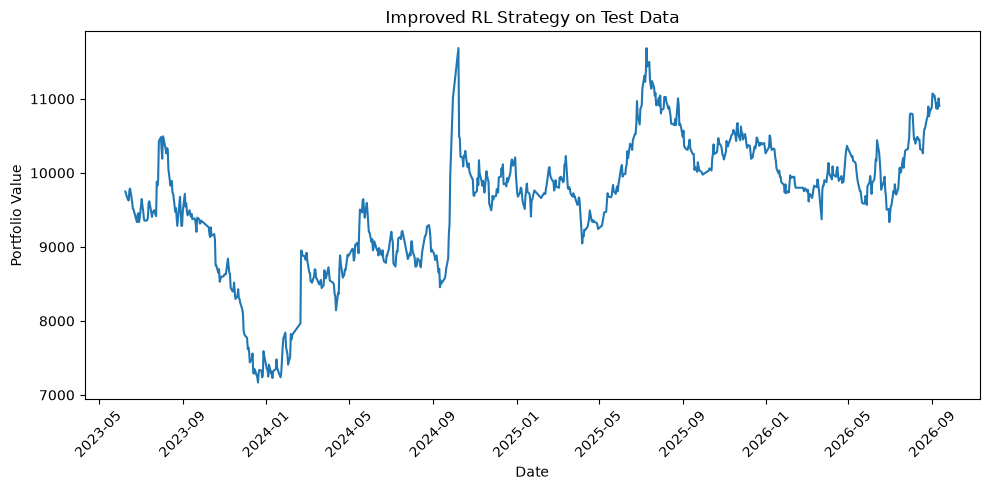

In [197]:
plt.figure(figsize=(10, 5))

plt.plot(
    improved_test_dates,
    improved_test_portfolio_values,
)

plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.title(
    "Improved RL Strategy on Test Data"
)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

###  TO DO LIST -> MA5_DISTANCE   
The current implementation uses end-of-day features and closing prices in a simplified trading simulation. A more realistic backtest should use only information available before execution, such as previous-day features with next-day open prices.

## 12. Compare with Baselines

### 12.1 Buy-and-Hold Baseline

In [ ]:
# Calculate the Buy-and-Hold baseline.
#在测试期第一天把钱全部买入股票，然后什么都不做，一直持有到测试期最后一天
# The strategy buys the stock at the beginning of the test period and holds it until the end.

buy_hold_start_price = test_df.iloc[0]["close"]
buy_hold_end_price = test_df.iloc[-1]["close"]

buy_hold_return = (
    buy_hold_end_price
    - buy_hold_start_price
) / buy_hold_start_price

buy_hold_final_value = (
    INITIAL_CASH
    * (1 + buy_hold_return)
)

print(
    f"Buy-and-Hold Final Value: "
    f"{buy_hold_final_value:.2f}"
)

print(
    f"Buy-and-Hold Return: "
    f"{buy_hold_return:.2%}"
)

Buy-and-Hold Final Value: 11846.62
Buy-and-Hold Return: 18.47%


The improved RL agent achieved a positive return of 9.05% on the test period, but underperformed the Buy-and-Hold baseline, which returned 18.47%.

### 12.2 Random Strategy Baseline

In [200]:
# Set a random seed so the result can be reproduced. 
np.random.seed(42)


# Reset the random-strategy portfolio.  
random_cash = INITIAL_CASH
random_shares = 0

 
random_portfolio_values = []
random_actions = []
random_dates = []

In [201]:
# Run a random trading strategy
# over the same unseen test period.

for i in range(len(test_df) - 1):

    current_row = test_df.iloc[i]
    next_row = test_df.iloc[i + 1]

    # Determine the current position.

    position = get_position(
        random_shares
    )


    # Only choose from valid actions.
    #
    # No position:
    # Hold or Buy
    #
    # Holding:
    # Hold or Sell

    if position == 0:
        valid_actions = [
            HOLD,
            BUY,
        ]
    else:
        valid_actions = [
            HOLD,
            SELL,
        ]


    # Randomly select one valid action.

    action = np.random.choice(
        valid_actions
    )


    # Execute the random action.
    #
    # The reward is not needed here because
    # this baseline does not learn anything.

    random_cash, random_shares, _ = (
        improved_trading_step(
            current_row=current_row,
            next_row=next_row,
            action=action,
            cash=random_cash,
            shares=random_shares,
        )
    )


    # Calculate portfolio value using
    # the next day's closing price.

    portfolio_value = get_portfolio_value(
        cash=random_cash,
        shares=random_shares,
        price=next_row["close"],
    )


    # Store the results.

    random_dates.append(
        next_row["date"]
    )

    random_portfolio_values.append(
        portfolio_value
    )

    random_actions.append(
        action
    )

In [202]:
# Calculate the final value and total return
# of the random strategy.

random_final_value = (
    random_portfolio_values[-1]
)

random_return = (
    random_final_value
    - INITIAL_CASH
) / INITIAL_CASH


print(
    f"Random Strategy Final Value: "
    f"{random_final_value:.2f}"
)

print(
    f"Random Strategy Return: "
    f"{random_return:.2%}"
)

Random Strategy Final Value: 6901.40
Random Strategy Return: -30.99%


In [203]:
# Count actions selected by the random strategy.

pd.Series(
    random_actions
).map(ACTION_NAMES).value_counts()

Hold    379
Buy     207
Sell    206
Name: count, dtype: int64

### 12.3 Strategy Comparison

The reinforcement-learning strategy is compared with:

- Buy-and-Hold
- Random trading

A positive return alone does not necessarily indicate a good strategy. A useful trading strategy should also be compared against simple baselines.

In [ ]:
# Compare final portfolio values
# and total returns across strategies.

comparison_df = pd.DataFrame({
    "Strategy": [
        "RL Strategy",
        "Buy and Hold",
        "Random Strategy",
    ],
    "Final Portfolio Value": [
        improved_final_portfolio_value,
        buy_hold_final_value,
        random_final_value,
    ],
    "Total Return": [
        improved_test_return,
        buy_hold_return,
        random_return,
    ],
})

# Create a formatted copy for display.

comparison_display = (
    comparison_df.copy()
)

comparison_display["Total Return"] = (
    comparison_display["Total Return"]
    .map(lambda x: f"{x:.2%}")
)

comparison_display

,Strategy,Final Portfolio Value,Total Return
0,RL Strategy,10905.072384,9.05%
1,Buy and Hold,11846.619576,18.47%
2,Random Strategy,6901.396560,-30.99%


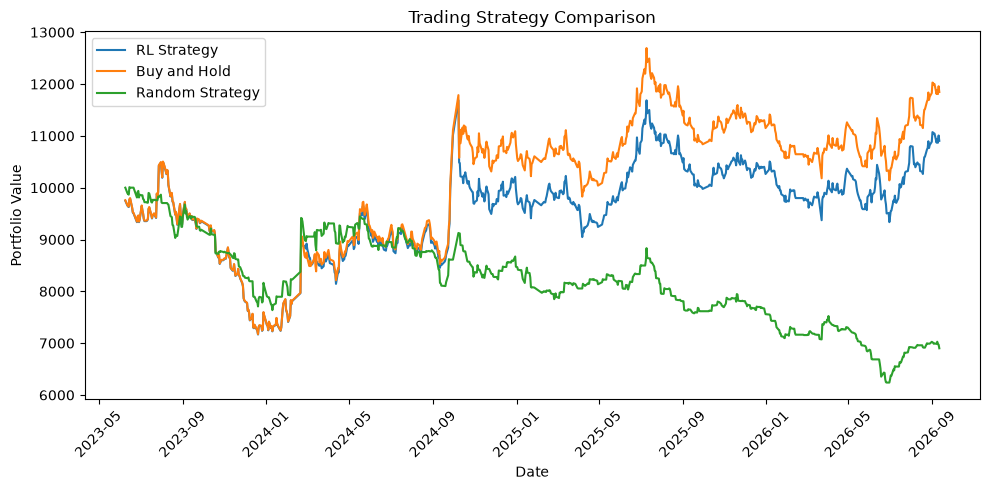

In [208]:
# Calculate the Buy-and-Hold portfolio value
# for every day in the test period.

buy_hold_values = (
    INITIAL_CASH
    * test_df.iloc[1:]["close"].values
    / test_df.iloc[0]["close"]
)

# Compare all three strategies
# over the same test period.

plt.figure(figsize=(10, 5))

plt.plot(
    improved_test_dates,
    improved_test_portfolio_values,
    label="RL Strategy",
)

plt.plot(
    improved_test_dates,
    buy_hold_values,
    label="Buy and Hold",
)

plt.plot(
    random_dates,
    random_portfolio_values,
    label="Random Strategy",
)

plt.xlabel("Date")
plt.ylabel("Portfolio Value")

plt.title(
    "Trading Strategy Comparison"
)

plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## 13. Results, Limitations and Future Improvements

### 13.1 Results

The improved Q-learning agent achieved a positive return of approximately 9.05% on the unseen test period.

The strategy clearly outperformed the random-trading baseline, which produced a return of approximately -30.99%.

However, the RL strategy underperformed the Buy-and-Hold baseline, which achieved approximately 18.47% over the same test period.

This suggests that the agent learned a meaningful trading policy, but the current state representation and reward design were not sufficient to outperform a simple passive investment strategy.

### 13.2 Limitations

- The Q-learning state space is highly simplified and only uses trend, volatility, and position.
- Continuous market information is discretised into a small number of states, which may lose useful information.
- The trading strategy uses a simplified all-in / all-out position model.
- Only one stock is evaluated.
- Transaction costs are simplified.
- The reward function is based on one-step performance relative to the market.
- The current backtest uses end-of-day features and closing prices, which is a simplified execution assumption.
- Market risk, slippage, liquidity, and taxes are not modelled.

### 13.3 Future Improvements

Future experiments could explore:

- richer market states using RSI, moving-average relationships, volume indicators, and momentum features
- partial position sizing instead of all-in / all-out trading
- more realistic execution using previous-day information and next-day opening prices
- multiple stocks and longer testing periods
- improved reward functions that consider risk-adjusted return and drawdown
- deep reinforcement learning methods such as DQN or PPO
- comparison with supervised-learning trading signals